## Notebook for simulating MIRI/MRS data from planetary systems

- Library of MIRI-MRS PSFs + possibility to use VHS 1256 b data cubes to simulate the planet
- ExoREM model spectra

In [1]:
import os, glob, pickle
from scipy.interpolate import interp1d
import numpy as np
import itertools
import h5py

from ExoCAT.correlation import get_exorem_spectra
from ExoCAT.mrs_tools import load_cube_dir
from ExoCAT.simul import *

from tqdm import tqdm
import xarray as xr

# Plotting tools
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
fs=14

system_name = "name_system" # name to save plots

# Output directory
output_dir = f"./{system_name}_simulations/"
os.makedirs(output_dir, exist_ok=True)

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


### Define useful path and parameters

In [2]:
# MIRI bands, wavelength ranges, and pixel scales
bands = ["1A","1B","1C","2A","2B","2C","3A","3B","3C"]
wave_band = {"1A": (4.90, 5.74), "1B": (5.66, 6.63), "1C": (6.53, 7.65),
             "2A": (7.51, 8.77), "2B": (8.67, 10.13), "2C": (10.01, 11.70),
             "3A": (11.55, 13.47), "3B": (13.34, 15.57), "3C": (15.41, 17.98)}
mrs_pixel_scales = {"1A": 0.196, "1B": 0.196, "1C": 0.196,
                    "2A": 0.196, "2B": 0.196, "2C": 0.196,
                    "3A": 0.245, "3B": 0.245, "3C": 0.245}

In [3]:
# Simulations parameters

# Fixed parameters :
logg, met, co, fsed = 4.25, 0.0, 0.55, 9 #surface gravity, metalicity, C/O ratio and Fsed (9 = no clouds to 0.3 = more clouds)
RJup = 1.02       # planet radius in RJup
dist_star = 3.5   # distance in pc

theta_deg = 80 # angle in degrees

# Varying parameters :
Teff = np.array([225, 275, 350]) # temperature values
offset_planet = np.array([1.2, 2, 3]) # in arcsec

## Inputs

### 1. Spectra

In [4]:
# Stellar spectrum
data61CygA = np.loadtxt("./Inputs/61CygA_spectrum.txt", delimiter=",")  # in W/m2/um
wave_star, flux_star = (data61CygA[:, 0], data61CygA[:, 1] * 1e6 * (data61CygA[:, 0] * 1e-6) ** 2 / 3e8 * 1e26 * 1e6)  # conv in uJy

# Planet spectrum - Model Exo-REM
ds = xr.open_dataset('./Inputs/ExoREM_200-450K_cloudy_fsed_2026.nc', decode_cf=False, engine="netcdf4",)
wave_planet, flux_planet = get_exorem_spectra(ds, Teff, logg, met, co, fsed, RJup, dist_star)

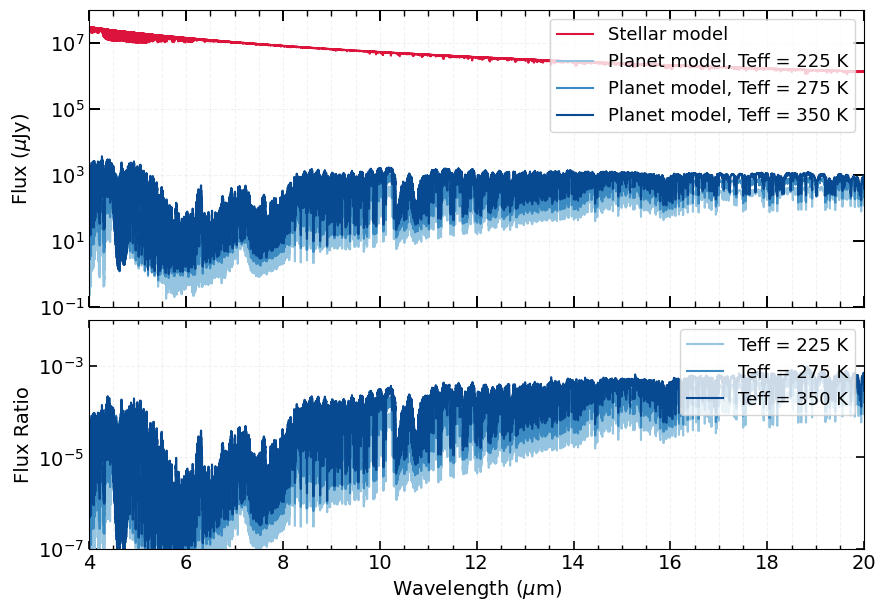

In [5]:
##### PLOTS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.05})
fs = 14

# --- Top panel: input spectra -----------------------------------------
ax1.plot(wave_star, flux_star, label="Stellar model", color="crimson", alpha=1)
planet_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(Teff)))
for teff, color in zip(Teff, planet_colors):
    ax1.plot(wave_planet, flux_planet[teff], label=f"Planet model, Teff = {teff} K", color=color, alpha=1)
ax1.set_ylabel("Flux ($\\mu$Jy)", fontsize=fs)
ax1.set_yscale("log")
ax1.set_ylim(1e-1, 1e8)
ax1.set_xlim(4, 20)
ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax1.tick_params(which="major", length=8, width=1.4, labelsize=fs)
ax1.tick_params(which="minor", length=4, width=1.0)
ax1.minorticks_on()
ax1.legend(fontsize=fs - 1, loc="upper right")

# --- Interpolate the stellar spectrum onto the planet grid, once --------
stellar_flux = interp1d(
    wave_star, flux_star, kind="linear", bounds_error=False, fill_value="extrapolate"
)(wave_planet)

# --- Bottom panel: contrast, for each Teff -------------------------------
for teff, color in zip(Teff, planet_colors):
    contrast = flux_planet[teff] / stellar_flux
    ax2.plot(wave_planet, contrast, color=color, label=f"Teff = {teff} K")
ax2.set_xlabel("Wavelength ($\\mu$m)", fontsize=fs)
ax2.set_ylabel("Flux Ratio", fontsize=fs)
ax2.set_yscale("log")
ax2.set_xlim(4, 20)
ax2.set_ylim(1e-7, 1e-2)
ax2.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax2.tick_params(which="major", length=6, width=1.2, labelsize=fs)
ax2.tick_params(which="minor", length=3, width=1.0)
ax2.minorticks_on()
ax2.legend(fontsize=fs - 1, loc="upper right")
ax1.grid(alpha=0.1, which='both', linestyle='--', color='gray')
ax2.grid(alpha=0.1, which='both', linestyle='--', color='gray')
plt.savefig(
    os.path.join(output_dir, f"Input_spectra_{system_name}.png"),
    bbox_inches="tight",
    pad_inches=0)
plt.show()

### 2. MRS Cubes

#### 2.1 Upload the library of MIRI MRS PSFs

In [6]:
mrs_psfs = {'1538' :  np.array([1,2,3]),
            '1536' : np.array([22,23,24])} # more PSFs available in the library

mrs_star_cube_all = {}
for prog_num, obs_list in mrs_psfs.items():
    mrs_star_cube_all[prog_num] = {}
    for obs_num in obs_list:
        path_mrs_data = f'./Inputs/MRS_refs_new/{prog_num}/cubes_obs{obs_num}/stage3/'   
        mrs_star = load_cube_dir(path_mrs_data)
        mrs_star_cube = {}
        for band in mrs_star.keys():
            mrs_star_cube[band] = np.where(np.isnan(mrs_star[band]['cube']), 0, mrs_star[band]['cube']) * 1e6  # in µJy
        mrs_star_cube_all[prog_num][obs_num] = mrs_star_cube

# Mean on all prog_num, obs_num for each band + first padding to make sure they have the same size
mrs_star_cube_avg, mrs_wavelengths = {},{}
all_bands = set()

# Extract all bands
for prog_data in mrs_star_cube_all.values():
    for obs_data in prog_data.values():
        all_bands.update(obs_data.keys())

for band in all_bands:
    cubes, shapes = [], []
    # Cubes in each band
    for prog_data in mrs_star_cube_all.values():
        for obs_data in prog_data.values():
            if band in obs_data:
                cube = obs_data[band]
                shapes.append(cube.shape)
                cubes.append(cube)
    if not cubes:
        continue

    # Max shape
    max_shape = np.max(np.array(shapes), axis=0)
    # Simple Padding
    def pad_cube(cube, target_shape):
        pad_width = [(0, t - s) for s, t in zip(cube.shape, target_shape)]
        return np.pad(cube, pad_width, mode='constant', constant_values=np.nan)

    padded_cubes = [pad_cube(cube, max_shape) for cube in cubes]
    mrs_wavelengths[band] = mrs_star[band]['wav']
    mrs_star_cube[band] = np.nanmean(padded_cubes, axis=0)

#### 2.1 Upload the VHS 1256 b MRS data

In [7]:
path_mrs_data = './Inputs/VHS1256b_datacubes/'
mrs_planet = load_cube_dir(path_mrs_data)
mrs_data_planet = {}
for band in bands:
    mrs_data_planet[band] = np.where(np.isnan(mrs_planet[band]['cube']), 0, mrs_planet[band]['cube'])
    mrs_data_planet[band] *= 1e6  # convert into µJy

## Run the simulation.

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


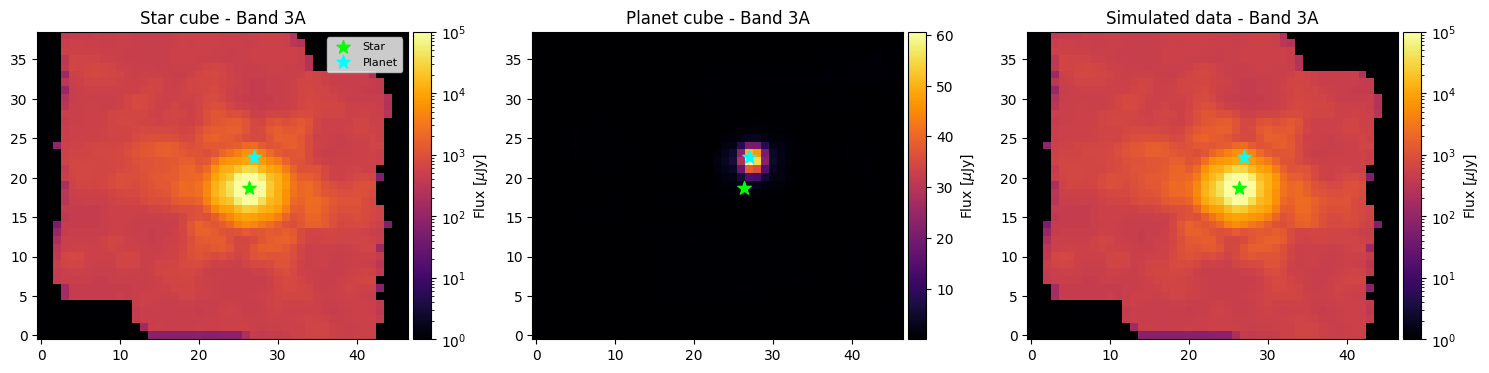

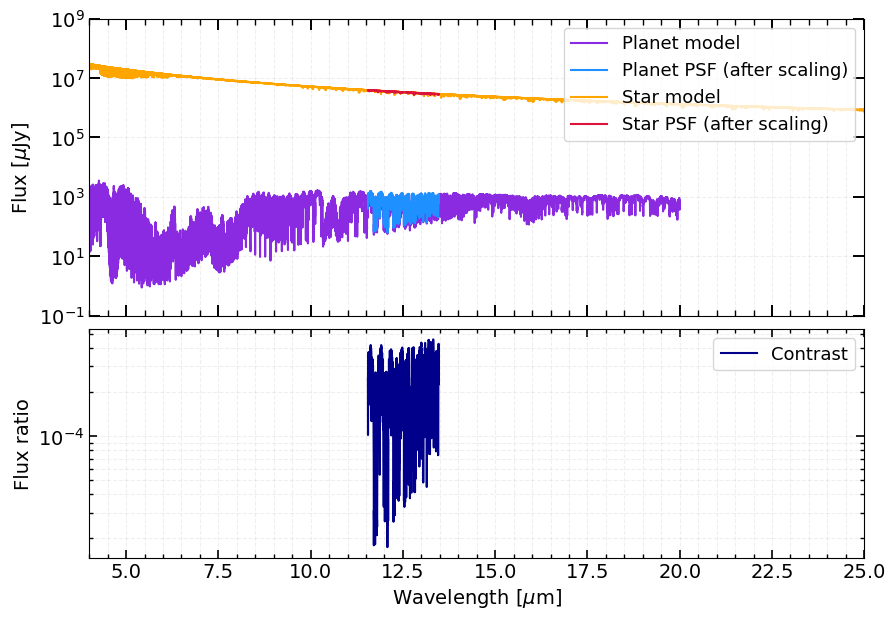

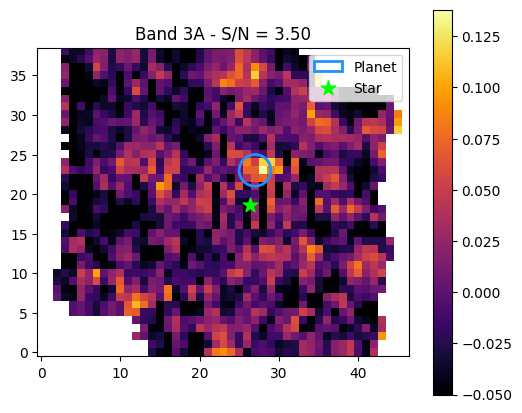

In [9]:
band = '3A'
res = simulation_MRS_single_band(
            wave_planet, flux_planet[350], # planet spectra (recale the flux at each wavelength)
            wave_star, flux_star, # stellar spectra (recale the flux at each wavelength)
            band = band, # MIRI MRS spectral band to simulate
            offset_planet = 1, # separation where to inject the planet
            theta_deg = theta_deg, # angle where to inject the planet
            mrs_star_cube = mrs_star_cube[band], # MIRI MRS PSF for the star (default is a STPSF simulation)
            mrs_wavelengths = mrs_wavelengths[band], # need to provide the mrs_wavelengths array
            mrs_planet_cube = mrs_data_planet[band], # MIRI MRS PSF for the planet (default in a STPSF simulation)
            plot_cubes=True, plot_models=True, plots_maps=True) # default plots to check the inputs and results

### Run simulations for a set of parameters :

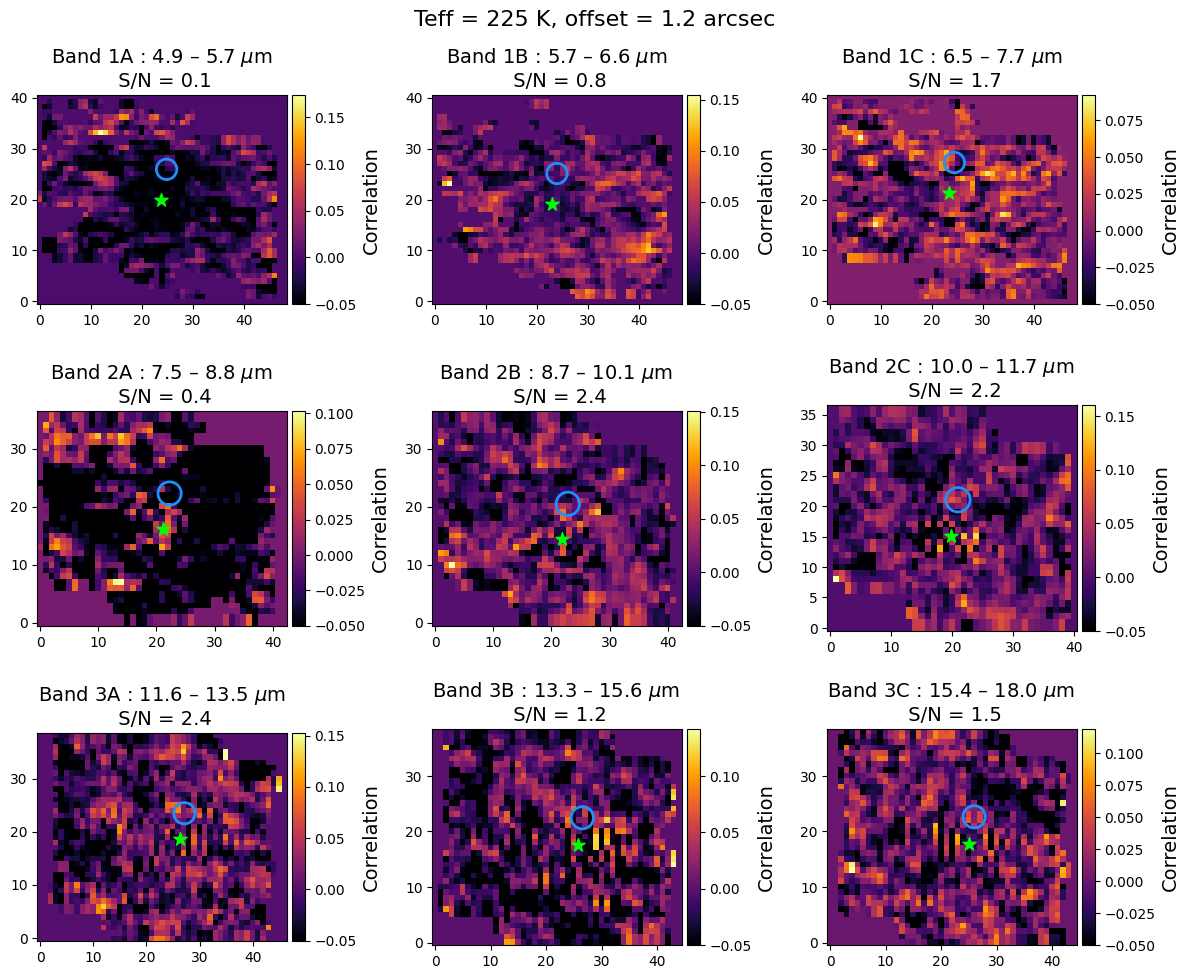

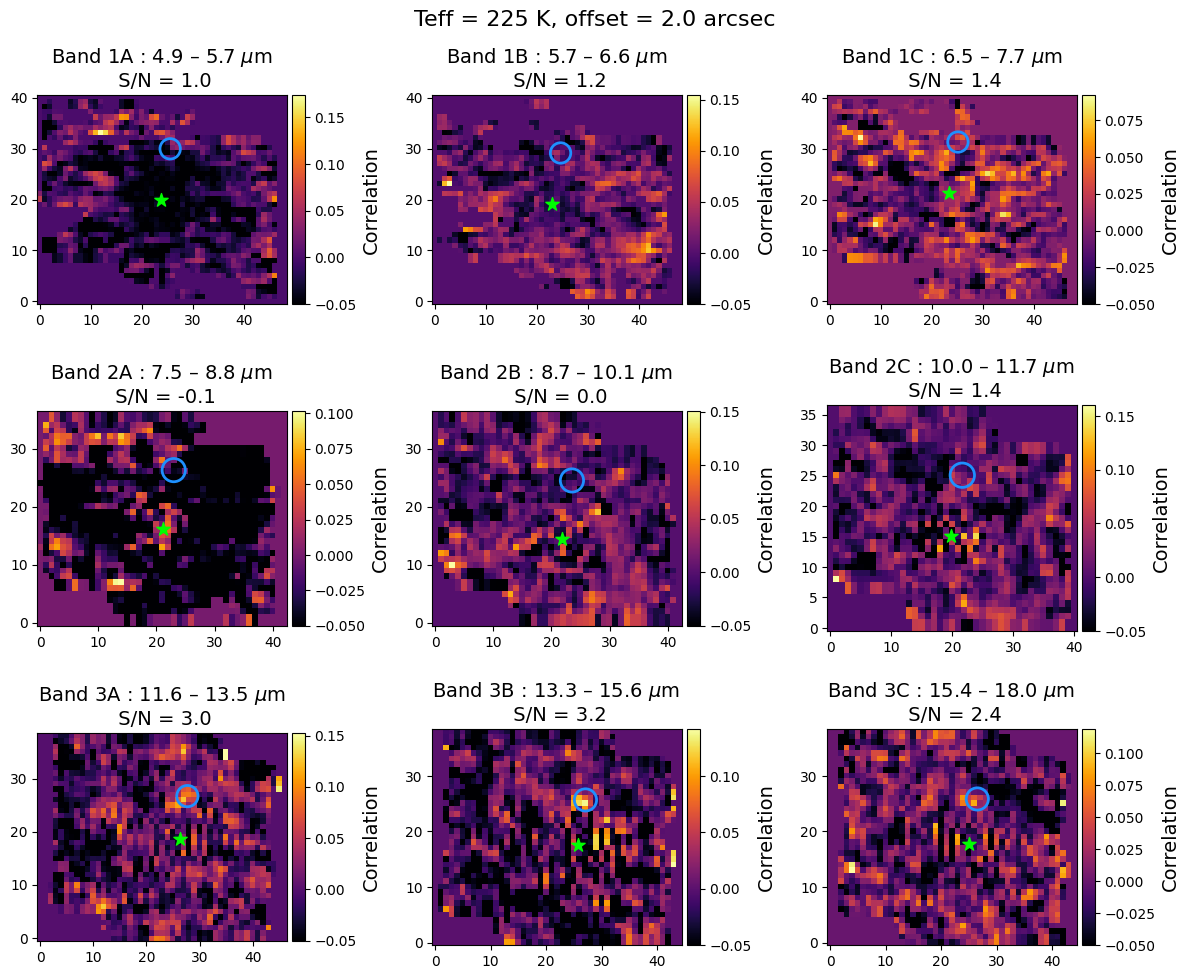

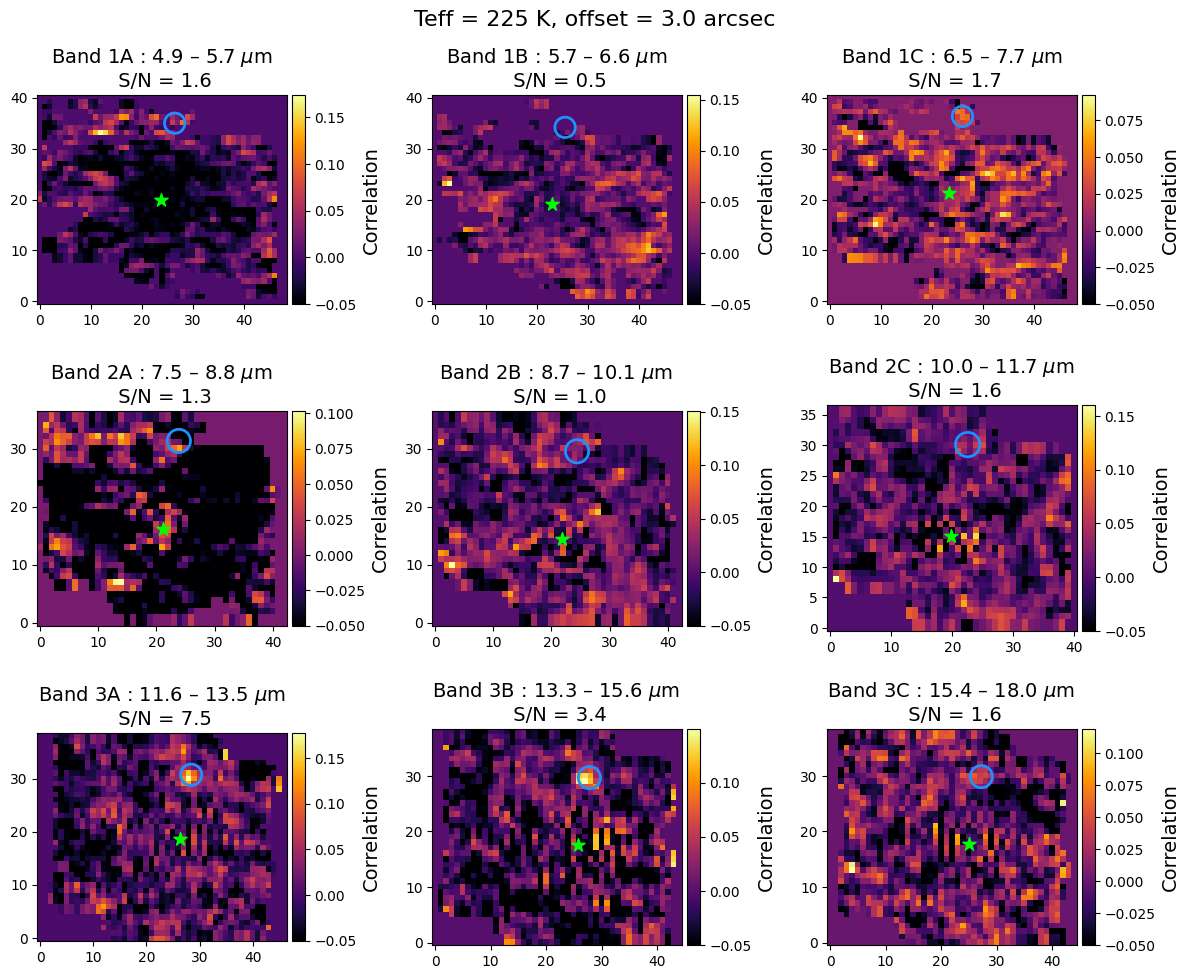

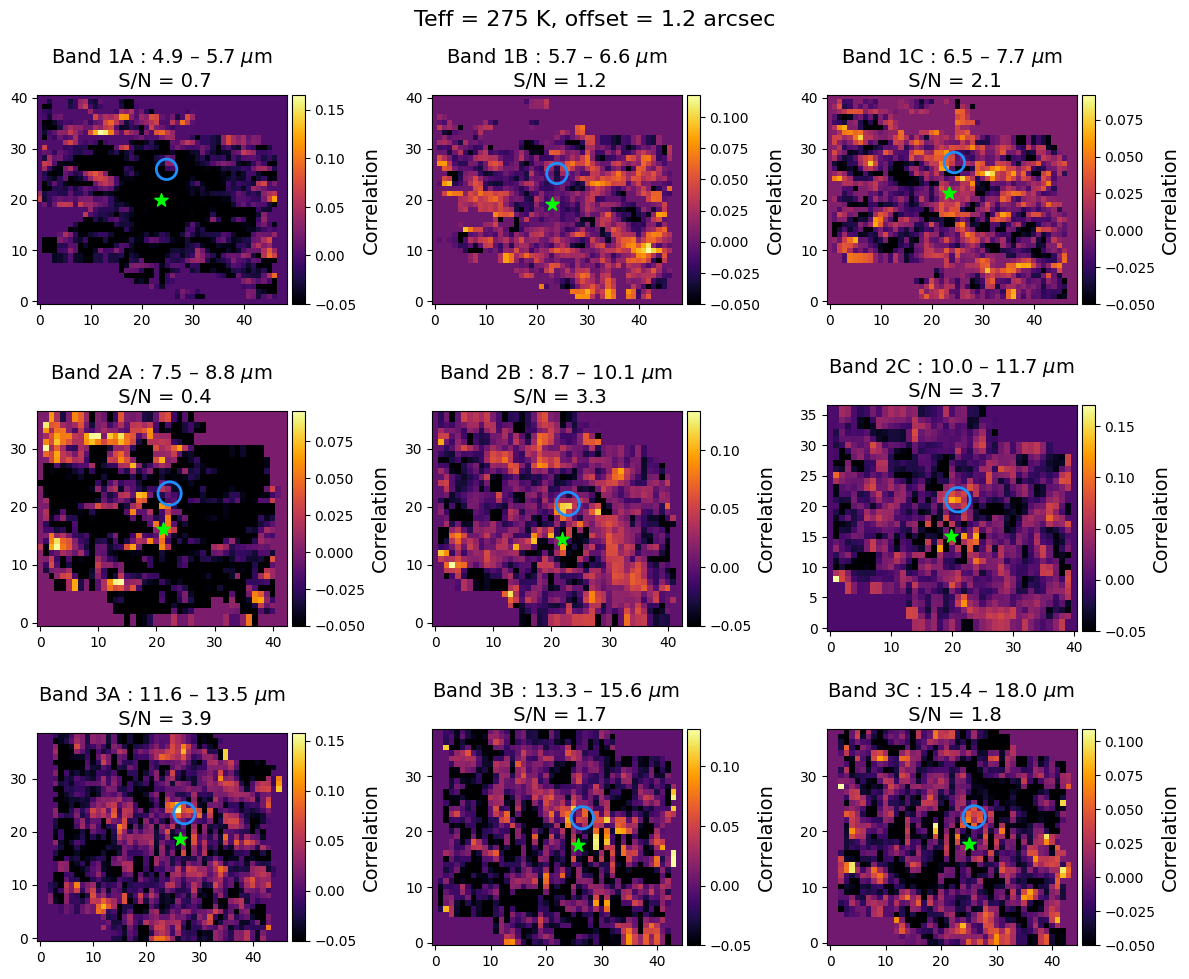

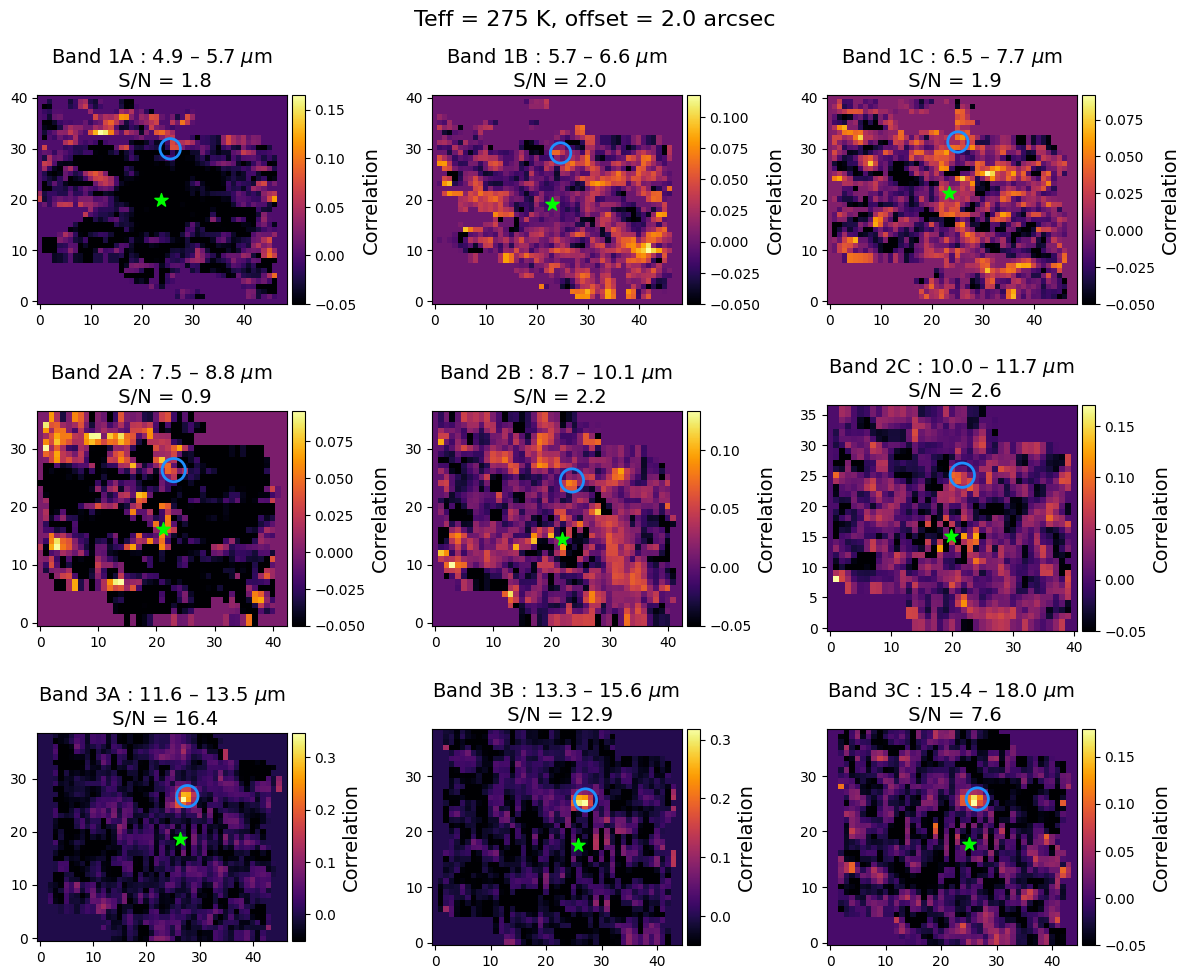

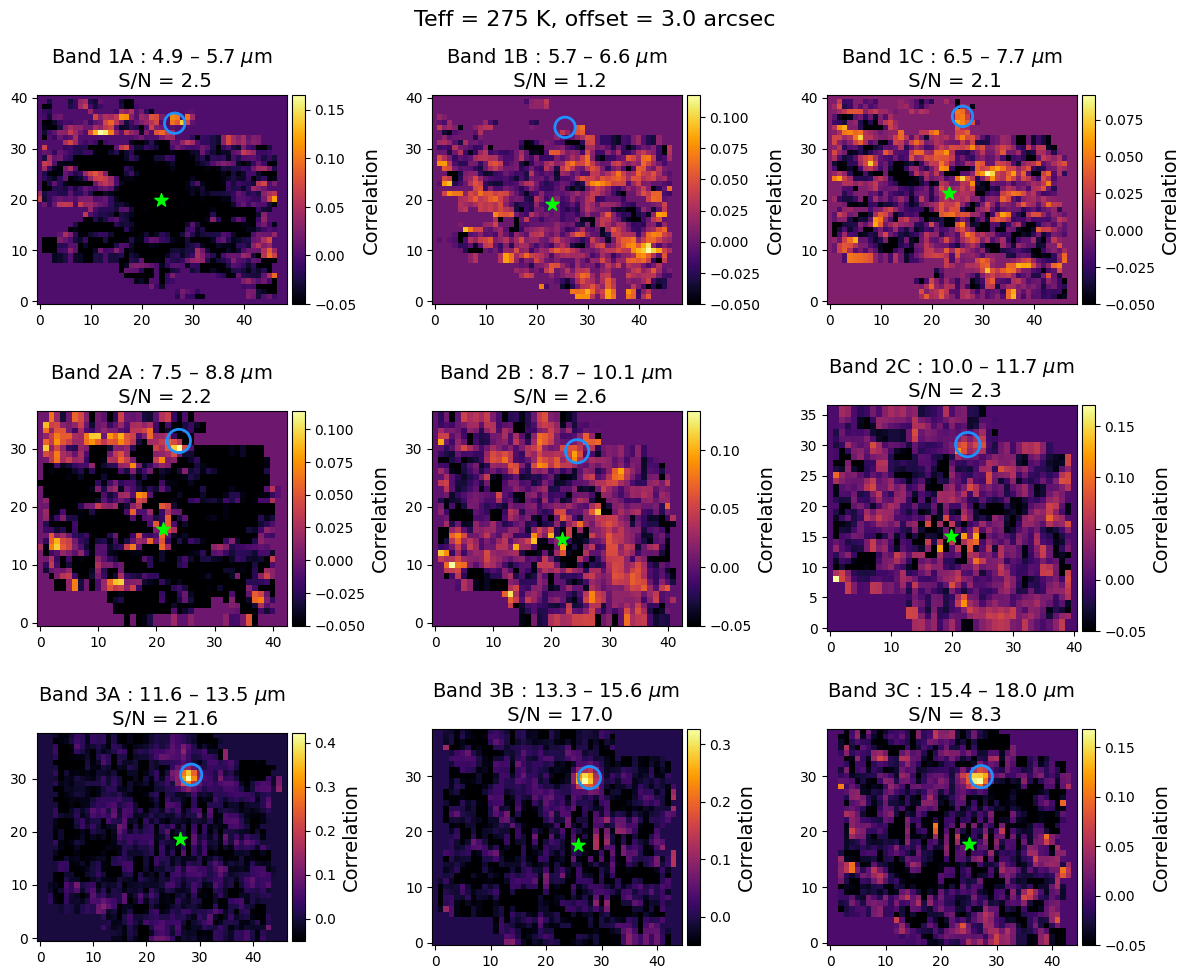

In [ ]:
SNR = {}
cc_maps = {}
simulated_data = {}
mrs_wave = {}
pos_planet = {}
pos_star = {}

# Run for 3 Teff values and 3 offset values 
for teff, offset in itertools.product(Teff, offset_planet):
    key = (teff, offset)
    SNR[key] = {}
    cc_maps[key] = {}
    simulated_data[key] = {}
    mrs_wave[key] = {}
    pos_planet[key] = {}
    pos_star[key] = {}

    # Run for all bands :
    for band in bands:
        (
            SNR[key][band],
            cc_maps[key][band],
            simulated_data[key][band],
            mrs_wave[key][band],
            pos_planet[key][band],
            pos_star[key][band],
        ) = simulation_MRS_single_band(
            wave_planet, flux_planet[teff],
            wave_star, flux_star,
            band=band,
            offset_planet=offset,
            mrs_star_cube=mrs_star_cube[band],
            theta_deg=theta_deg,
            mrs_wavelengths=mrs_wavelengths[band],
            plot_cubes=False, plot_models=False, plots_maps=False,
        )

    # Plot the correlation maps for this (Teff, offset) combination
    fig = plt.figure(figsize=(12, 10), tight_layout=False)
    for ch in range(len(bands)):
        ax = fig.add_subplot(3, 3, 1 + ch)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cc_map = np.nan_to_num(cc_maps[key][bands[ch]], nan=0.0)
        im = ax.imshow(cc_map, cmap="inferno", origin='lower', vmin=-0.05)
        cbar = fig.colorbar(im, cax=cax, orientation="vertical")
        cbar.set_label("Correlation", color="black", size=fs)
        ax.set_title(
            f"Band {bands[ch]} : {np.min(mrs_wave[key][bands[ch]]):.1f} – {np.max(mrs_wave[key][bands[ch]]):.1f} $\mu$m \n S/N = {SNR[key][bands[ch]]:.1f}",
            fontsize=fs)
        x_star, y_star = pos_star[key][bands[ch]]
        ax.scatter(x_star, y_star, c='lime', marker='*', s=100)
        x_planet, y_planet = pos_planet[key][bands[ch]]
        circle = plt.Circle((x_planet, y_planet), radius=2, edgecolor="dodgerblue", facecolor="none", linewidth=2,)
        ax.add_patch(circle)

    fig.suptitle(f"Teff = {teff} K, offset = {offset} arcsec", fontsize=fs + 2)
    plt.tight_layout()
    plt.savefig(output_dir+f"Correlation_maps_Teff{teff}_offset{offset}.png", bbox_inches="tight")
    plt.show()